# Study v2: gated nationality diagnostic

This notebook shows sample structure and power. It does not fit or release an adjusted nationality
effect because the prespecified release gate fails.

In [1]:
# ruff: noqa: E402
import json
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".jupyter" / "mplconfig"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

STRICT = ROOT / "data/manual/study_v2_strict_model_audit/strict-model-audit-0fe15fd6b052"
REVIEW = ROOT / "data/manual/study_v2_review_packets/study-v2-review-7cb1b29b5251"
REFERRAL = ROOT / "data/manual/study_v2_referrals/referrals-a4f9bd038101"
CLOCK = ROOT / "data/manual/study_v2_incident_clock/incident-clock-3dc8bb350308"
CONTEXT = ROOT / "data/manual/study_v2_incident_context/incident-context-707a44aafeb4"
CLOSE = ROOT / "data/manual/study_v2_close_cases/close-cases-b175fe03fa80"
DAMAGE = ROOT / "data/manual/study_v2_damage/damage-screening-23c77a57134e"
LAYERS = ROOT / "data/manual/study_v2_layers/study-v2-layers-eed6774fb6c5"
NATIONALITY = ROOT / "data/manual/study_v2_nationality/nationality-diagnostic-2b1b0ffdd961"
GENERATED = ROOT / "reports/generated/study_v2"
GENERATED.mkdir(parents=True, exist_ok=True)

In [2]:
gate = pd.read_csv(NATIONALITY / "release_gate.csv")
rates = pd.read_csv(NATIONALITY / "descriptive_rates.csv")
power = pd.read_csv(NATIONALITY / "simulation_power.csv")
overlap = pd.read_csv(NATIONALITY / "overlap_summary.csv")
display(rates)
display(gate.T.rename(columns={0: "value"}))
display(overlap.T.rename(columns={0: "value"}))
assert bool(gate.loc[0, "formal_effect_release_gate"]) is False

,british_accused_driver,cases,sanctions,group,sanction_rate
0,False,302,189,Other accused driver,0.625828
1,True,44,25,British accused driver,0.568182


,value
rows,346
british_accused_rows,44
minimum_british_accused_rows,98
target_risk_difference,0.15
minimum_power_at_target_difference,0.378
overlap_status,usable_overlap
minimum_common_support_fraction,0.9
maximum_weighted_abs_smd,0.1
minimum_exposed_effective_sample_size,30
independent_human_review_complete,False


,value
rows,346
events,131
exposed_rows,44
unexposed_rows,302
exposure_prevalence,0.127168
propensity_auc,0.70304
propensity_min,0.01
propensity_max,0.622265
common_support_lower,0.018455
common_support_upper,0.364435


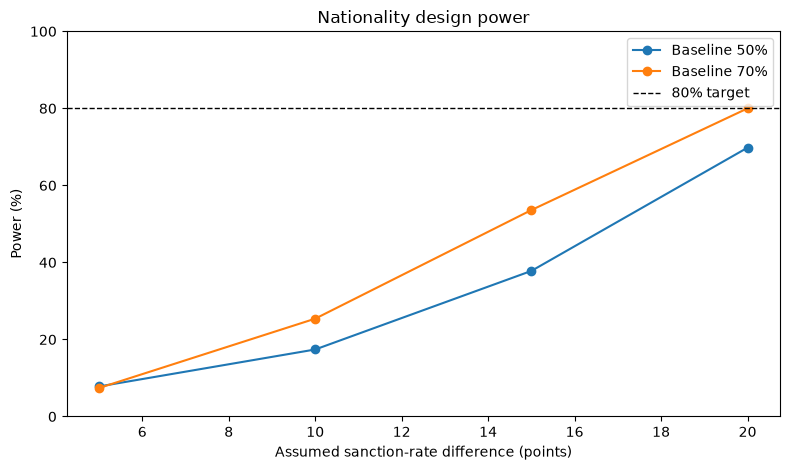

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.8))
for baseline, group in power.groupby("baseline_probability"):
    ax.plot(group["target_risk_difference"] * 100, group["detection_power"] * 100, marker="o", label=f"Baseline {baseline:.0%}")
ax.axhline(80, color="black", linestyle="--", linewidth=1, label="80% target")
ax.set(title="Nationality design power", xlabel="Assumed sanction-rate difference (points)", ylabel="Power (%)", ylim=(0, 100))
ax.legend()
plt.tight_layout()
plt.savefig(GENERATED / "nationality_power_v2.png", dpi=160, bbox_inches="tight")
plt.show()

Measured overlap is usable, but there are only 44 British-accused cases versus the frozen minimum
of 98. At the target 15-point difference, simulated power ranges from 37.8% to 53.6%. Independent
review is also incomplete. The correct result is **inconclusive**, not evidence for or against bias.